EXPERIMENT 7: RANDOM FORESTS
OOB ERROR, BAGGING AND FEATURE SUBSAMPLING

Dataset Shape: (100000, 12)

Columns:
['name', 'gender', 'status', 'affiliation', 'faction', 'role', 'weapon', 'emotion', 'mission_count', 'location', 'rank', 'loyalty']

First 5 Rows:


,name,gender,status,affiliation,faction,role,weapon,emotion,mission_count,location,rank,loyalty
0,Viggo Tarasov,Male,Excommunicated,Ruska Roma,Ruska Roma,Courier,Poison,strategic,2,Continental NYC,5,9
1,Sasha,Female,Excommunicated,Continental NYC,Continental NYC,Cleaner,Poison,vengeful,1,Berlin,9,8
2,Young Charon O'Connor,Male,Excommunicated,The Desert,The Desert,Scout,Bare Hands,furious,1,Ruska Roma,3,5
3,Marcus,Male,Excommunicated,Berlin,Berlin,Manager,Pistol,nervous,4,High Table,2,5
4,Charlie,Male,Deceased,High Table,High Table,Sniper,Knife,grieving,3,Continental NYC,6,9



Missing Values:
name             0
gender           0
status           0
affiliation      0
faction          0
role             0
weapon           0
emotion          0
mission_count    0
location         0
rank             0
loyalty          0
dtype: int64

Duplicate Rows: 4

Encoded Features: 62
Training Rows: 80000
Testing Rows: 20000

Decision Tree Accuracy: 33.76 %
Bagging Accuracy: 33.24 %
Bagging OOB Error: 66.55 %
Random Forest Accuracy: 33.84 %
Random Forest OOB Accuracy: 33.17 %
Random Forest OOB Error: 66.83 %

MODEL COMPARISON


,Model,Test Accuracy,OOB Accuracy,OOB Error,Feature Sampling
0,Decision Tree,0.33755,NaN,NaN,All
1,Bagging,0.33240,0.33445,0.66555,All
2,Random Forest,0.33845,0.33175,0.66825,sqrt



OOB ERROR VS NUMBER OF TREES


,Number of Trees,OOB Error,OOB Accuracy
0,10,0.665088,0.334912
1,20,0.666287,0.333713
2,30,0.668950,0.331050
3,40,0.668250,0.331750



FEATURE SUBSAMPLING RESULTS


,Max Features,Test Accuracy,OOB Accuracy,OOB Error
0,sqrt,0.33900,0.333713,0.666287
1,log2,0.33670,0.333437,0.666562
2,1.0,0.33185,0.334450,0.665550


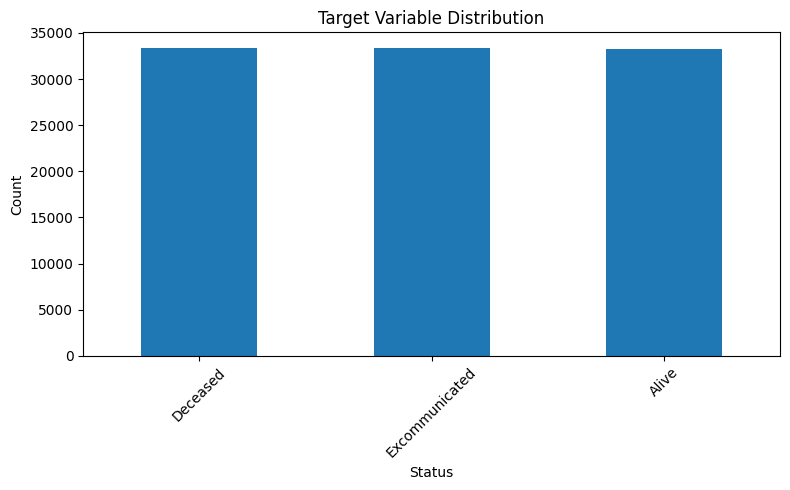

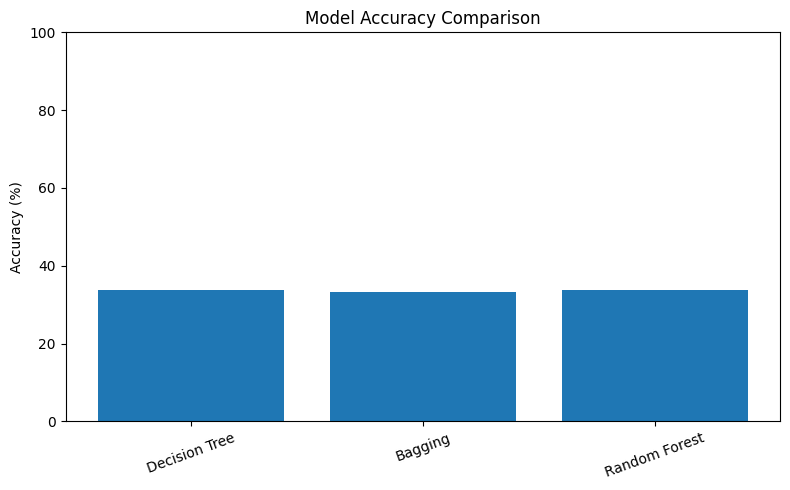

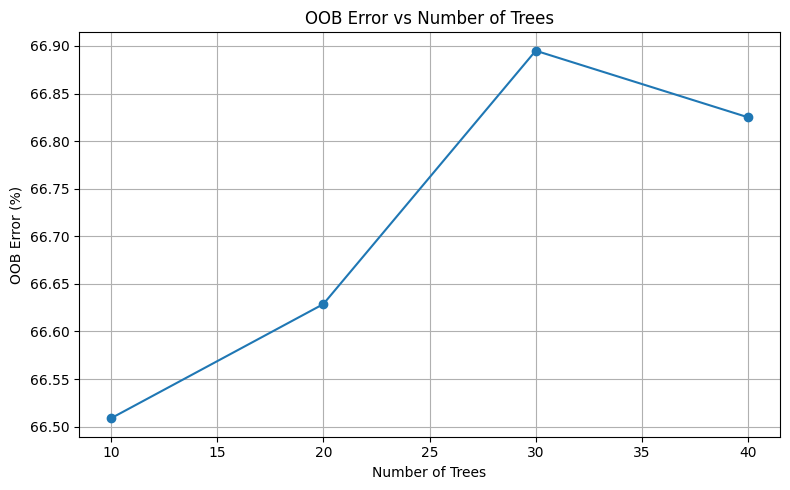

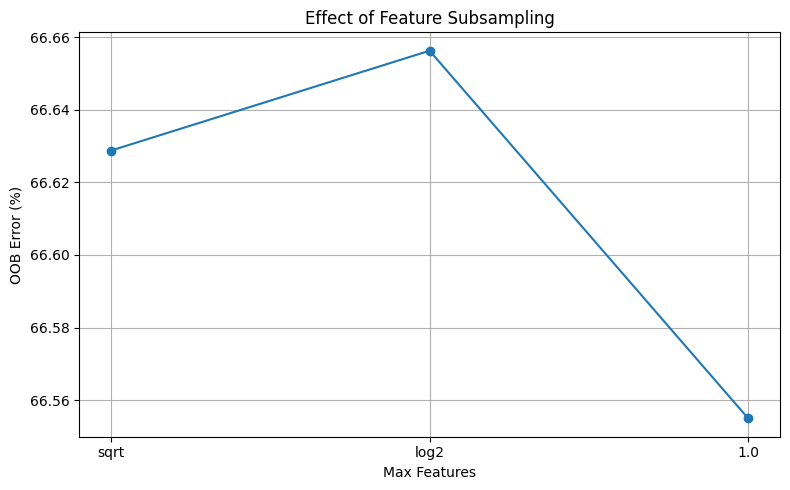

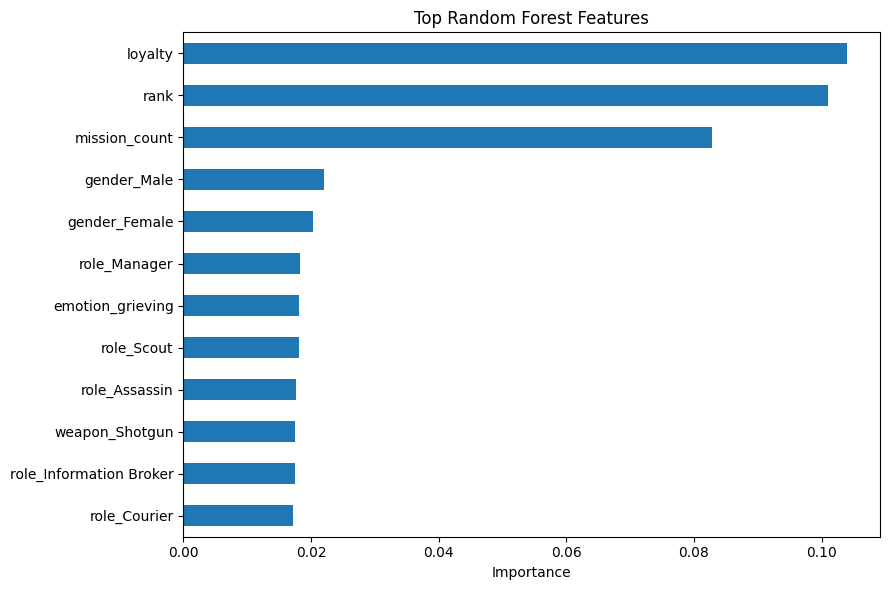

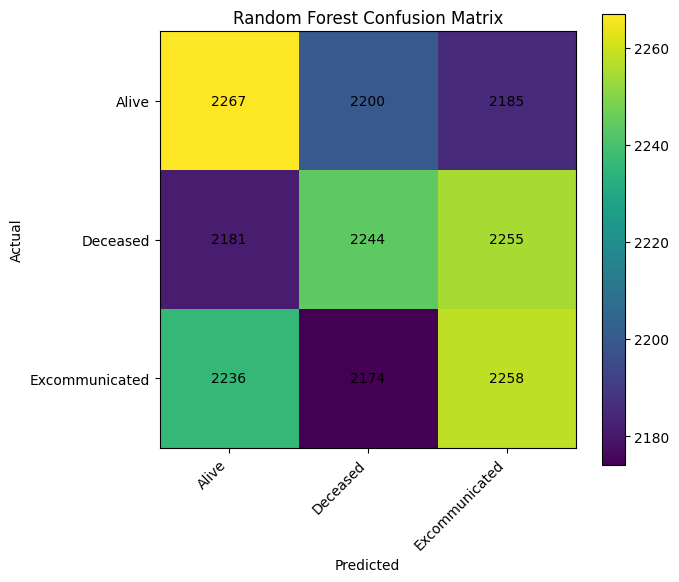

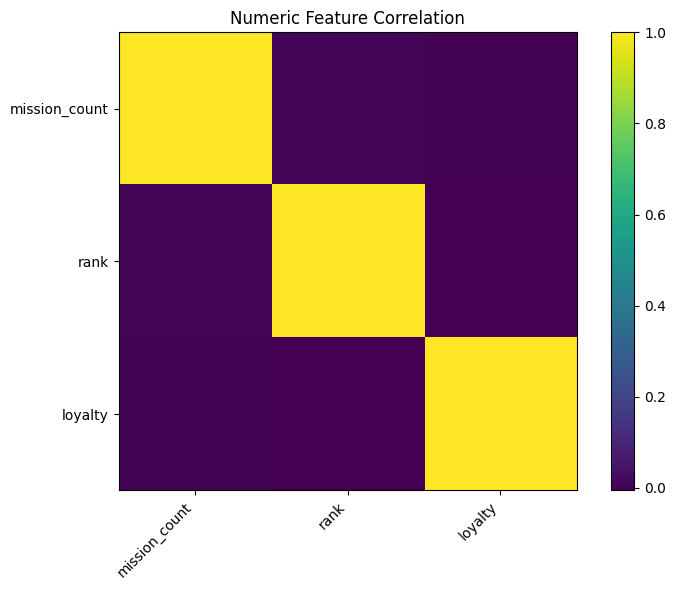


EXPERIMENT 7 COMPLETED SUCCESSFULLY

Final Random Forest Accuracy: 33.84 %
Final Random Forest OOB Error: 66.83 %

Generated:
✓ 01_target_distribution.png
✓ 02_model_accuracy.png
✓ 03_oob_error.png
✓ 04_feature_subsampling.png
✓ 05_feature_importance.png
✓ 06_confusion_matrix.png
✓ 07_correlation.png
✓ Experiment_7_EDA_Report.pdf
✓ classification_report.csv
✓ feature_importance.csv
✓ feature_subsampling.csv
✓ model_comparison.csv
✓ oob_error_vs_trees.csv
✓ sample_dataset.csv



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os, warnings, zipfile
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files

FILE_PATH = "/content/John_Wick_Universe_Synthetic_Dataset.csv"
OUT = "/content/Experiment_7_Results"
os.makedirs(OUT, exist_ok=True)

df = pd.read_csv(FILE_PATH)

print("=" * 65)
print("EXPERIMENT 7: RANDOM FORESTS")
print("OOB ERROR, BAGGING AND FEATURE SUBSAMPLING")
print("=" * 65)

print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(list(df.columns))

print("\nFirst 5 Rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

target = "status"

X = df.drop(columns=[target, "name"], errors="ignore")
y = df[target].astype(str)

cat = X.select_dtypes(include="object").columns
num = X.select_dtypes(exclude="object").columns

X[cat] = X[cat].fillna("Unknown")
X[num] = X[num].fillna(X[num].median())

X = pd.get_dummies(X, columns=cat, drop_first=False)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nEncoded Features:", X.shape[1])
print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))

results = []

dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)

results.append([
    "Decision Tree",
    dt_acc,
    np.nan,
    np.nan,
    "All"
])

print("\nDecision Tree Accuracy:", round(dt_acc * 100, 2), "%")

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
    n_estimators=20,
    max_samples=0.7,
    max_features=1.0,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

bag.fit(X_train, y_train)

bag_pred = bag.predict(X_test)
bag_acc = accuracy_score(y_test, bag_pred)
bag_oob = bag.oob_score_

results.append([
    "Bagging",
    bag_acc,
    bag_oob,
    1 - bag_oob,
    "All"
])

print("Bagging Accuracy:", round(bag_acc * 100, 2), "%")
print("Bagging OOB Error:", round((1 - bag_oob) * 100, 2), "%")

rf = RandomForestClassifier(
    n_estimators=40,
    max_features="sqrt",
    max_samples=0.7,
    bootstrap=True,
    oob_score=True,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_oob = rf.oob_score_

results.append([
    "Random Forest",
    rf_acc,
    rf_oob,
    1 - rf_oob,
    "sqrt"
])

print("Random Forest Accuracy:", round(rf_acc * 100, 2), "%")
print("Random Forest OOB Accuracy:", round(rf_oob * 100, 2), "%")
print("Random Forest OOB Error:", round((1 - rf_oob) * 100, 2), "%")

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Test Accuracy",
        "OOB Accuracy",
        "OOB Error",
        "Feature Sampling"
    ]
)

results_df.to_csv(
    f"{OUT}/model_comparison.csv",
    index=False
)

print("\nMODEL COMPARISON")
display(results_df)

tree_values = [10, 20, 30, 40]
oob_values = []

rf_curve = RandomForestClassifier(
    n_estimators=10,
    max_features="sqrt",
    max_samples=0.7,
    bootstrap=True,
    oob_score=True,
    max_depth=12,
    warm_start=True,
    random_state=42,
    n_jobs=-1
)

for n in tree_values:
    rf_curve.set_params(n_estimators=n)
    rf_curve.fit(X_train, y_train)
    oob_values.append(1 - rf_curve.oob_score_)

oob_df = pd.DataFrame({
    "Number of Trees": tree_values,
    "OOB Error": oob_values,
    "OOB Accuracy": [1 - x for x in oob_values]
})

oob_df.to_csv(
    f"{OUT}/oob_error_vs_trees.csv",
    index=False
)

print("\nOOB ERROR VS NUMBER OF TREES")
display(oob_df)

feature_settings = ["sqrt", "log2", 1.0]
subsample_results = []

for setting in feature_settings:
    model = RandomForestClassifier(
        n_estimators=20,
        max_features=setting,
        max_samples=0.7,
        bootstrap=True,
        oob_score=True,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)

    subsample_results.append([
        str(setting),
        acc,
        model.oob_score_,
        1 - model.oob_score_
    ])

subsample_df = pd.DataFrame(
    subsample_results,
    columns=[
        "Max Features",
        "Test Accuracy",
        "OOB Accuracy",
        "OOB Error"
    ]
)

subsample_df.to_csv(
    f"{OUT}/feature_subsampling.csv",
    index=False
)

print("\nFEATURE SUBSAMPLING RESULTS")
display(subsample_df)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(12)

importance.to_csv(
    f"{OUT}/feature_importance.csv",
    header=["Importance"]
)

figures = []

plt.figure(figsize=(8, 5))
df[target].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
path = f"{OUT}/01_target_distribution.png"
plt.savefig(path, dpi=120)
figures.append(path)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(
    results_df["Model"],
    results_df["Test Accuracy"] * 100
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=20)
plt.tight_layout()
path = f"{OUT}/02_model_accuracy.png"
plt.savefig(path, dpi=120)
figures.append(path)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    oob_df["Number of Trees"],
    oob_df["OOB Error"] * 100,
    marker="o"
)
plt.title("OOB Error vs Number of Trees")
plt.xlabel("Number of Trees")
plt.ylabel("OOB Error (%)")
plt.grid(True)
plt.tight_layout()
path = f"{OUT}/03_oob_error.png"
plt.savefig(path, dpi=120)
figures.append(path)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    subsample_df["Max Features"],
    subsample_df["OOB Error"] * 100,
    marker="o"
)
plt.title("Effect of Feature Subsampling")
plt.xlabel("Max Features")
plt.ylabel("OOB Error (%)")
plt.grid(True)
plt.tight_layout()
path = f"{OUT}/04_feature_subsampling.png"
plt.savefig(path, dpi=120)
figures.append(path)
plt.show()

plt.figure(figsize=(9, 6))
importance.sort_values().plot(kind="barh")
plt.title("Top Random Forest Features")
plt.xlabel("Importance")
plt.tight_layout()
path = f"{OUT}/05_feature_importance.png"
plt.savefig(path, dpi=120)
figures.append(path)
plt.show()

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(
    range(len(rf.classes_)),
    rf.classes_,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(rf.classes_)),
    rf.classes_
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
path = f"{OUT}/06_confusion_matrix.png"
plt.savefig(path, dpi=120)
figures.append(path)
plt.show()

numeric = df.select_dtypes(include=np.number)

if numeric.shape[1] >= 2:
    plt.figure(figsize=(8, 6))
    plt.imshow(numeric.corr())
    plt.colorbar()
    plt.xticks(
        range(len(numeric.columns)),
        numeric.columns,
        rotation=45,
        ha="right"
    )
    plt.yticks(
        range(len(numeric.columns)),
        numeric.columns
    )
    plt.title("Numeric Feature Correlation")
    plt.tight_layout()
    path = f"{OUT}/07_correlation.png"
    plt.savefig(path, dpi=120)
    figures.append(path)
    plt.show()

report = classification_report(
    y_test,
    rf_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).T

report_df.to_csv(
    f"{OUT}/classification_report.csv"
)

sample = df.sample(
    min(10, len(df)),
    random_state=42
)

sample.to_csv(
    f"{OUT}/sample_dataset.csv",
    index=False
)

with PdfPages(f"{OUT}/Experiment_7_EDA_Report.pdf") as pdf:

    fig = plt.figure(figsize=(11, 8.5))
    plt.axis("off")

    text = f"""
EXPERIMENT 7
RANDOM FORESTS — OOB ERROR, BAGGING AND FEATURE SUBSAMPLING

Dataset:
{os.path.basename(FILE_PATH)}

Dataset Shape:
{df.shape[0]} rows × {df.shape[1]} columns

Target:
{target}

Training Rows:
{len(X_train)}

Testing Rows:
{len(X_test)}

Encoded Features:
{X.shape[1]}

Missing Values:
{df.isnull().sum().sum()}

Duplicate Rows:
{df.duplicated().sum()}

DECISION TREE
Accuracy: {dt_acc:.4f}

BAGGING
Trees: 20
Accuracy: {bag_acc:.4f}
OOB Accuracy: {bag_oob:.4f}
OOB Error: {1-bag_oob:.4f}

RANDOM FOREST
Trees: 40
Accuracy: {rf_acc:.4f}
OOB Accuracy: {rf_oob:.4f}
OOB Error: {1-rf_oob:.4f}

CONCEPTS IMPLEMENTED
• Decision Tree baseline
• Bootstrap Aggregation
• Bagging
• Random Forest
• Out-of-Bag Accuracy
• Out-of-Bag Error
• Feature Subsampling
• OOB Error vs Number of Trees
• Feature Importance
• Model Comparison
"""

    plt.text(
        0.05,
        0.95,
        text,
        va="top",
        fontsize=12,
        family="monospace"
    )

    pdf.savefig(fig)
    plt.close()

    for image in figures:
        img = plt.imread(image)
        fig = plt.figure(figsize=(11, 8.5))
        plt.imshow(img)
        plt.axis("off")
        pdf.savefig(fig, bbox_inches="tight")
        plt.close()

zip_path = "/content/Experiment_7_Random_Forest_Results.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files_list in os.walk(OUT):
        for file in files_list:
            full = os.path.join(root, file)
            z.write(full, os.path.relpath(full, OUT))

print("\n" + "=" * 65)
print("EXPERIMENT 7 COMPLETED SUCCESSFULLY")
print("=" * 65)

print("\nFinal Random Forest Accuracy:",
      round(rf_acc * 100, 2), "%")

print("Final Random Forest OOB Error:",
      round((1 - rf_oob) * 100, 2), "%")

print("\nGenerated:")
for f in sorted(os.listdir(OUT)):
    print("✓", f)

print("\nDownloading complete results ZIP...")
files.download(zip_path)